In [ ]:
# Supervised Machine Learning
# Classification -- Logistic Regression

# Sigmoid Function

import numpy as np
from sklearn.linear_model import LogisticRegression

# creating a dummy dataset
x = np.array([[1],[2],[3],[4],[5],[6]])   # hours_studied
y = np.array([0,0,0,1,1,1])               # pass or not

# create and train the model
model = LogisticRegression()
model.fit(x,y)

LogisticRegression()

In [ ]:
# predict_proba() stands for predict probabilities
y_prob = model.predict_proba(x)[:,1]  # all rows from column 1
y_prob

array([0.05723731, 0.15697456, 0.36349699, 0.63656293, 0.84305971,
       0.94277666])

In [ ]:
# Get the slope and intercept
a = model.coef_[0][0]       # SLOPE
b = model.intercept_[0]     # INTERCEPT

print(f'Slope: {a}')
print(f'Intercept: {b}')

Slope: 1.1206952510393666
Intercept: -3.9223038967769632


In [ ]:
# Compute the score
# if a student is studying for 3 hours
# the formula is a*x+b

score = (1.1207)*(3)+(-3.9223)
print(score)

-0.5602


In [ ]:
import math
res = (math.e) ** (-score)
print(res)

1.7510226698119447


In [ ]:
1 / (1 + res)

0.36350118484060273

In [ ]:
# Compute the score
# if a student is studying for 5.5 hours

score = (1.1207)*(5.5)+(-3.9223)
print(score)

2.24155


In [ ]:
import math
res = (math.e) ** (-score)
print(res)

0.10629362151469593


In [ ]:
1 / (1 + res)

0.9039191590301654

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

data = pd.read_csv('https://raw.githubusercontent.com/yashy1626/mydatasets/refs/heads/main/diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
# Select independent and dependent variable
x = data.drop('Outcome', axis=1) # axis = 1 means column
y = data['Outcome']

In [ ]:
# train_test_split
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Model Development

# What does max_iter=1000 mean?
'''
When the model is learning from data, it doesn’t get everything perfect in one go. It:

Makes a guess
Checks how wrong it is
Adjusts itself
Repeats this process again and again

Each repeat is called an iteration.

👉 max_iter=1000 means:

“You are allowed to try improving yourself up to 1000 times before stopping.”


🧩 Why is this important?

Sometimes the model needs more time (more iterations) to learn properly.

If the number is too small → model may stop too early and not learn well ❌
If it's bigger (like 1000) → gives the model more chances to improve ✅


🧾 In short:

LogisticRegression(max_iter=1000) means:

“Create a model that makes yes/no predictions, and allow it up to 1000 attempts to learn the best way to do that.”

'''
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# predict_proba() stands for predicr probabilities
y_prob = log_reg.predict_proba(x_test)[:,1] # all rows from column 1
y_prob

array([0.27587171, 0.18844086, 0.11448808, 0.16354446, 0.47152763,
       0.44181565, 0.01545949, 0.66077894, 0.54146137, 0.77733211,
       0.25591838, 0.89734144, 0.3362008 , 0.30303447, 0.08198096,
       0.38092464, 0.13935392, 0.07479528, 0.86674191, 0.56143057,
       0.20841338, 0.07739483, 0.53962428, 0.0945844 , 0.5394989 ,
       0.88554595, 0.12431327, 0.03016297, 0.25152958, 0.11581437,
       0.91112978, 0.87075938, 0.76536041, 0.83753319, 0.61668745,
       0.68328935, 0.96813003, 0.24363738, 0.51147551, 0.73613825,
       0.06983479, 0.59412645, 0.58366935, 0.32718599, 0.02759122,
       0.50239275, 0.6393479 , 0.22533799, 0.36056256, 0.95629563,
       0.04889599, 0.66096112, 0.8116769 , 0.24552928, 0.09325806,
       0.04152087, 0.7781665 , 0.0057039 , 0.40861817, 0.75696165,
       0.74134846, 0.35194245, 0.19236789, 0.20492144, 0.07688254,
       0.62716494, 0.0509161 , 0.7328617 , 0.03691982, 0.71593403,
       0.67523613, 0.07016495, 0.18115143, 0.11430304, 0.09115

In [ ]:
# get the predicted values
y_pred = log_reg.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test,y_pred)
cm

# Total Observation : 154 (total no. of predicted outcome)                  78 + 37 = 115 (Good predictions)
#                                                                           21 + 18 = 39 (Bad Predictions)
#                              predicted non_diabetic  predicted diabetic       RECALL
# y = 0 (actual non-diabetic)        TN = 78               FP = 21           TN / TN + FP
# y = 1 (actual diabetic)            FN = 18               TP = 37           TP / TP + FN
#   PRECISION                     TN / TN + FN           TP / TP + FN

array([[78, 21],
       [18, 37]])

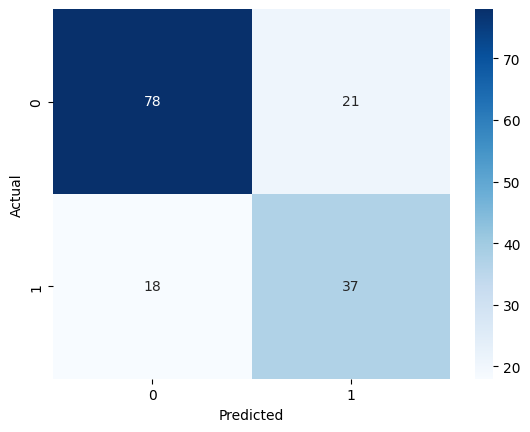

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(cm,cmap='Blues',annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print('Classification Report')
print(classification_report(y_test,y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

